In [1]:
import pandas as pd
import numpy as np
import sys
import os
import joblib

# import some libraries for training
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer, PowerTransformer
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.compose import TransformedTargetRegressor
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error
import matplotlib.pyplot as plt

from helper_modules import phase2_preprocess_data, perform_one_hot_encode

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

# disable some warnings
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="hyperopt")


In [2]:
df = pd.read_csv(os.path.join('datasets', 'flextrack_phase1_train.csv'))
print(df.shape)
display(df.head())

(105120, 7)


,Site,Timestamp_Local,Dry_Bulb_Temperature_C,Global_Horizontal_Radiation_W/m2,Building_Power_kW,Demand_Response_Flag,Demand_Response_Capacity_kW
0,siteA,2019-01-01 00:00:00,22.20,0.0,4.8,0,0.0
1,siteA,2019-01-01 00:15:00,22.27,0.0,4.8,0,0.0
2,siteA,2019-01-01 00:30:00,22.35,0.0,4.8,0,0.0
3,siteA,2019-01-01 00:45:00,22.42,0.0,4.8,0,0.0
4,siteA,2019-01-01 01:00:00,22.50,0.0,4.8,0,0.0


In [3]:
# Try extracting data that has Demand_Response_Flag = 0 and Demand_Response_Capacity_kW != 0.0
df1 = df[
    (df['Demand_Response_Flag']==0) &
    (df['Demand_Response_Capacity_kW'] != 0.0)
].copy(deep=True)
print (df1.shape[0])

df1 = df[
    df['Demand_Response_Flag']==0
].copy(deep=True)
df2 = df1[
    df1['Demand_Response_Capacity_kW'] != 0.0
].copy(deep=True)
print (df2.shape[0])
# We observe that if Demand_Response_Flag = 0, then Demand_Response_Capacity_kW is always 0.0

0
0


,Demand_Response_Capacity_kW,quarter,month,week,day,dow,doy,hour,minute,second,is_weekend,is_month_start,is_month_end,is_quarter_end,is_year_end,P_lag_1,P_lag_1h,P_lag_3h,P_lag_6h,P_lag_12h,P_lag_24h,P_rolling_mean_1h,P_rolling_median_1h,P_rolling_std_1h,P_rolling_max_1h,P_rolling_min_1h,P_rolling_mean_3h,P_rolling_median_3h,P_rolling_std_3h,P_rolling_max_3h,P_rolling_min_3h,P_rolling_mean_6h,P_rolling_median_6h,P_rolling_std_6h,P_rolling_max_6h,P_rolling_min_6h,P_rolling_mean_12h,P_rolling_median_12h,P_rolling_std_12h,P_rolling_max_12h,P_rolling_min_12h,P_rolling_mean_24h,P_rolling_median_24h,P_rolling_std_24h,P_rolling_max_24h,P_rolling_min_24h,P_same_hour_yday,P_same_hour_lweek,P_delta_1,P_pctchg_1,...,W_rolling_std_12h,W_rolling_max_12h,W_rolling_min_12h,W_rolling_mean_24h,W_rolling_median_24h,W_rolling_std_24h,W_rolling_max_24h,W_rolling_min_24h,W_same_hour_yday,W_same_hour_lweek,W_delta_1,W_pctchg_1,T_lag_1,T_lag_1h,T_lag_3h,T_lag_6h,T_lag_12h,T_lag_24h,T_rolling_mean_1h,T_rolling_median_1h,T_rolling_std_1h,T_rolling_max_1h,T_rolling_min_1h,T_rolling_mean_3h,T_rolling_median_3h,T_rolling_std_3h,T_rolling_max_3h,T_rolling_min_3h,T_rolling_mean_6h,T_rolling_median_6h,T_rolling_std_6h,T_rolling_max_6h,T_rolling_min_6h,T_rolling_mean_12h,T_rolling_median_12h,T_rolling_std_12h,T_rolling_max_12h,T_rolling_min_12h,T_rolling_mean_24h,T_rolling_median_24h,T_rolling_std_24h,T_rolling_max_24h,T_rolling_min_24h,T_same_hour_yday,T_same_hour_lweek,T_delta_1,T_pctchg_1,Demand_Response_Flag_-1,Demand_Response_Flag_0,Demand_Response_Flag_1
0,0.0,1,1,1,1,1,1,11,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
1,0.0,1,1,1,1,1,1,11,0,0,0,1,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1,0
2,0.0,1,1,1,1,1,1,11,15,0,0,1,0,0,0,4.8,NaN,NaN,NaN,NaN,NaN,4.8,4.8,0.0,4.8,4.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,18.39,NaN,NaN,NaN,NaN,NaN,20.2950,20.295,2.694077,22.20,18.39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-3.81,-0.171622,0,1,0
3,0.0,1,1,1,1,1,1,11,15,0,0,1,0,0,0,4.8,NaN,NaN,NaN,NaN,NaN,4.8,4.8,0.0,4.8,4.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,22.20,NaN,NaN,NaN,NaN,NaN,19.6200,18.390,2.235151,22.20,18.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.12,-0.006525,0,1,0
4,0.0,1,1,1,1,1,1,11,30,0,0,1,0,0,0,4.8,NaN,NaN,NaN,NaN,NaN,4.8,4.8,0.0,4.8,4.8,4.8,4.8,0.0,4.8,4.8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,22.27,NaN,NaN,NaN,NaN,NaN,20.2825,20.295,2.255266,22.27,18.27,20.2825,20.295,2.255266,22.27,18.27,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,0.218938,0,1,0


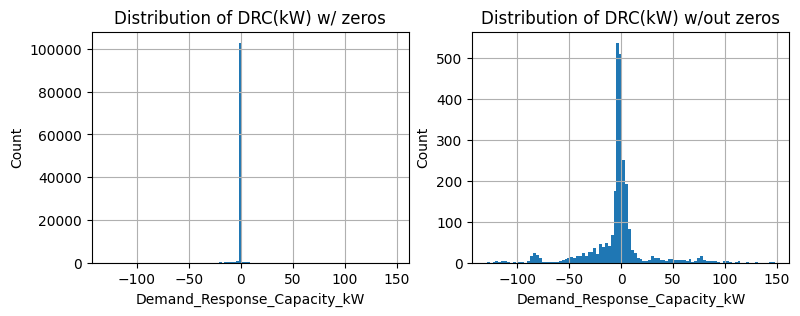

In [4]:
# perform some preprocessing
df = phase2_preprocess_data(df)
df = perform_one_hot_encode(df, col_name='Demand_Response_Flag')
display(df.head())

# Visualize the distribution of Demand_Response_Capacity_kW
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(9, 3))
df['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax1)
ax1.set_title('Distribution of DRC(kW) w/ zeros')
ax1.set_xlabel('Demand_Response_Capacity_kW')
ax1.set_ylabel('Count')

df[
    df['Demand_Response_Capacity_kW'] != 0.0
]['Demand_Response_Capacity_kW'].hist(bins=100, ax=ax2)
ax2.set_title('Distribution of DRC(kW) w/out zeros')
ax2.set_xlabel('Demand_Response_Capacity_kW')
ax2.set_ylabel('Count')
plt.show()

In [5]:
# suspects.remove('Building_Power_kW')
df = df.drop_duplicates()
X = df.drop(columns=['Demand_Response_Capacity_kW'])
y = df['Demand_Response_Capacity_kW']

# --- TOP-LEVEL functions (picklable) ---
def asinh_scale(y, c=1.0):
    y = np.asarray(y)
    return np.arcsinh(y / c)

def inv_asinh_scale(z, c=1.0):
    z = np.asarray(z)
    return c * np.sinh(z)

# choose c once (e.g., median |nonzero y|)
def choose_c(y):
    y = np.asarray(y)
    nz = np.abs(y[np.abs(y) > 1e-12])
    return float(np.median(nz)) if nz.size else 1.0


def train_two_part_xgb(X: pd.DataFrame, y: pd.Series, random_state=42):
    # 0) Make zero-indicator for stratification & classification
    y_is_nonzero = (y != 0).astype(int)
    # 1) Train/valid split (stratify on zero vs nonzero)
    X_tr, X_te, y_tr, y_te, nz_tr, nz_te = train_test_split(
        X, y, y_is_nonzero, test_size=0.1, random_state=random_state, stratify=y_is_nonzero
    )

    # (Optional) scale numeric features if distributions are wildly different.
    # Keep it simple: scale everything numeric; tree models don't need it but it can help if you later swap models.
    X_tr_scaled = X_tr.copy()
    X_te_scaled = X_te.copy()
    # 2) Classifier: P(nonzero | x)
    pos = nz_tr.sum()
    neg = len(nz_tr) - pos
    scale_pos_weight = (neg / max(pos, 1)) if pos > 0 else 1.0
    clf = xgb.XGBClassifier(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=5.0,
        reg_alpha=0.5,
        min_child_weight=5.0,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=random_state,
        scale_pos_weight=scale_pos_weight
    )
    clf.fit(
        X_tr_scaled, nz_tr,
        eval_set=[(X_te_scaled, nz_te)],
        verbose=False,
    )
    # 3) Regressor on non-zeros: E[y | nonzero, x]
    mask_tr_nz = (y_tr != 0)
    mask_te_nz = (y_te != 0)
    # Use MAE objective (robust to outliers) – good default for messy tails
    reg = xgb.XGBRegressor(
        n_estimators=2000,
        tree_method='hist',
        max_depth=7,
        max_bin=256,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.7,
        reg_lambda=3.0,
        reg_alpha=0.1,
        gamma=0.0,
        min_child_weight=12,
        objective='reg:absoluteerror',  # a.k.a. MAE loss
        eval_metric='mae',
        random_state=random_state,
        n_jobs=-1
    )

    c = choose_c(y_tr)
    asinh_tf = FunctionTransformer(
        func=asinh_scale, inverse_func=inv_asinh_scale,
        kw_args={"c": c}, inv_kw_args={"c": c}, validate=False
    )
    reg = TransformedTargetRegressor(
        regressor=reg, 
        transformer=asinh_tf
        # func=np.arcsinh, inverse_func=np.sinh
    )

    reg.fit(
        X_tr_scaled[mask_tr_nz], y_tr[mask_tr_nz],
        eval_set=[(X_te_scaled[mask_te_nz], y_te[mask_te_nz])],
        verbose=False,
    )
    # 4) Inference: E[y] = P(nonzero|x)*E[y|nonzero,x]
    p_nonzero_te = clf.predict_proba(X_te_scaled)[:, 1]
    y_hat_cond_te = reg.predict(X_te_scaled)
    y_hat_te = p_nonzero_te * y_hat_cond_te
    # 5) Metrics
    rmse = np.sqrt(mean_squared_error(y_te, y_hat_te))
    mae = mean_absolute_error(y_te, y_hat_te)
    # extra diagnostics
    # classification quality on zero vs non-zero
    auc = roc_auc_score(nz_te, p_nonzero_te)
    # error on the hard part (non-zeros only)
    nz_mae = mean_absolute_error(y_te[mask_te_nz], y_hat_te[mask_te_nz]) if mask_te_nz.any() else np.nan
    nz_rmse = np.sqrt(mean_squared_error(y_te[mask_te_nz], y_hat_te[mask_te_nz])) if mask_te_nz.any() else np.nan
    results = {
        "Overall_MAE": mae,
        "Overall_RMSE": rmse,
        "Nonzero_MAE": nz_mae,
        "Nonzero_RMSE": nz_rmse,
        "ZeroRate_Test": 1 - nz_te.mean(),
        "Classifier_AUC": auc,
        'y_hat_te' : y_hat_te,
        'y_te' : y_te
    }
    return clf, reg, results

clf, reg, results = train_two_part_xgb(X,y)
print(
   results['Overall_MAE'],
   results['Overall_RMSE'],
   results['Nonzero_MAE'],
   results['Nonzero_RMSE'],
   results['ZeroRate_Test'],
   results['Classifier_AUC']
)

0.21513110413991438 2.5879854347556366 8.197597548398834 16.194584333348413 0.9752663622526636 0.9999699870944506


In [6]:
# Save models
joblib.dump(clf, './models/phase2_xgb_clf_nz_model.pkl')
joblib.dump(reg, './models/phase2_xgb_reg_nz_model.pkl')
print("Models saved.")

Models saved.


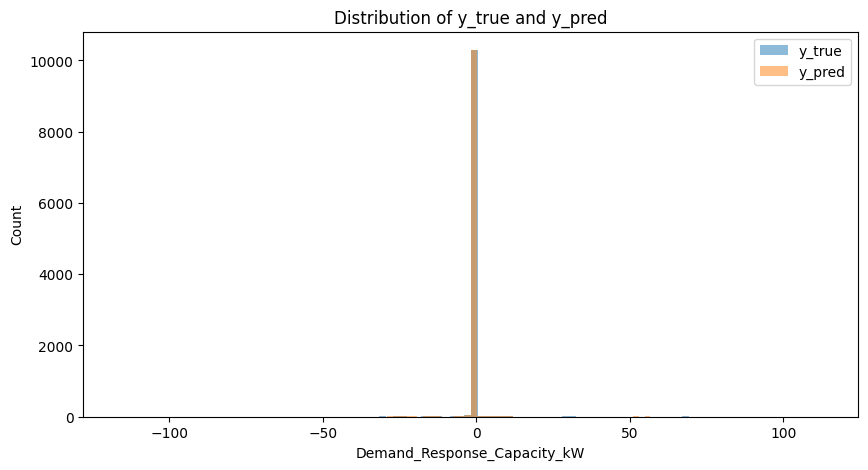

In [7]:
y_pred = results['y_hat_te']
y_true = results['y_te']

plt.figure(figsize=(10, 5))
plt.hist(y_true, bins=100, alpha=0.5, label='y_true')
plt.hist(y_pred, bins=100, alpha=0.5, label='y_pred')
plt.legend()
plt.xlabel('Demand_Response_Capacity_kW')
plt.ylabel('Count')
plt.title('Distribution of y_true and y_pred')
plt.show()

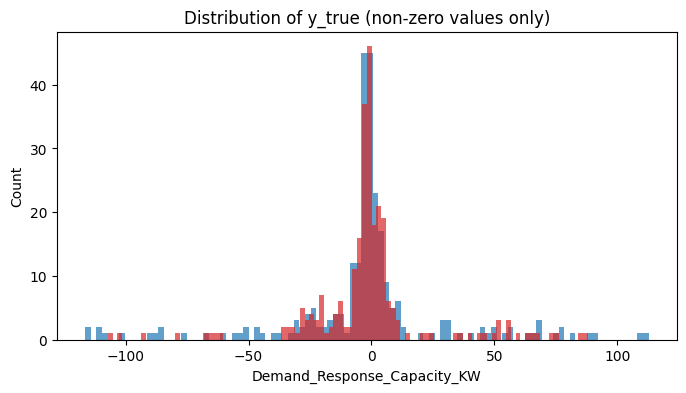

In [8]:
plt.figure(figsize=(8, 4))
y_true_nonzero = y_true[y_true != 0.0]
y_pred_nonzero = y_pred[y_true != 0.0]
plt.hist(y_true_nonzero, bins=100, alpha=0.7, color='tab:blue')
plt.hist(y_pred_nonzero, bins=100, alpha=0.7, color='tab:red')
plt.xlabel('Demand_Response_Capacity_KW')
plt.ylabel('Count')
plt.title('Distribution of y_true (non-zero values only)')
plt.show()

In [9]:
np.min(y_pred), np.max(y_pred), np.mean(y_pred), np.std(y_pred)

(np.float32(-107.2633),
 np.float32(87.93701),
 np.float32(-0.04350109),
 np.float32(3.8391147))

In [10]:
X.columns.tolist()

['quarter',
 'month',
 'week',
 'day',
 'dow',
 'doy',
 'hour',
 'minute',
 'second',
 'is_weekend',
 'is_month_start',
 'is_month_end',
 'is_quarter_end',
 'is_year_end',
 'P_lag_1',
 'P_lag_1h',
 'P_lag_3h',
 'P_lag_6h',
 'P_lag_12h',
 'P_lag_24h',
 'P_rolling_mean_1h',
 'P_rolling_median_1h',
 'P_rolling_std_1h',
 'P_rolling_max_1h',
 'P_rolling_min_1h',
 'P_rolling_mean_3h',
 'P_rolling_median_3h',
 'P_rolling_std_3h',
 'P_rolling_max_3h',
 'P_rolling_min_3h',
 'P_rolling_mean_6h',
 'P_rolling_median_6h',
 'P_rolling_std_6h',
 'P_rolling_max_6h',
 'P_rolling_min_6h',
 'P_rolling_mean_12h',
 'P_rolling_median_12h',
 'P_rolling_std_12h',
 'P_rolling_max_12h',
 'P_rolling_min_12h',
 'P_rolling_mean_24h',
 'P_rolling_median_24h',
 'P_rolling_std_24h',
 'P_rolling_max_24h',
 'P_rolling_min_24h',
 'P_same_hour_yday',
 'P_same_hour_lweek',
 'P_delta_1',
 'P_pctchg_1',
 'W_lag_1',
 'W_lag_1h',
 'W_lag_3h',
 'W_lag_6h',
 'W_lag_12h',
 'W_lag_24h',
 'W_rolling_mean_1h',
 'W_rolling_median_1h